In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

color_analytical = "#7402d8"  # purple

output_dir = "."

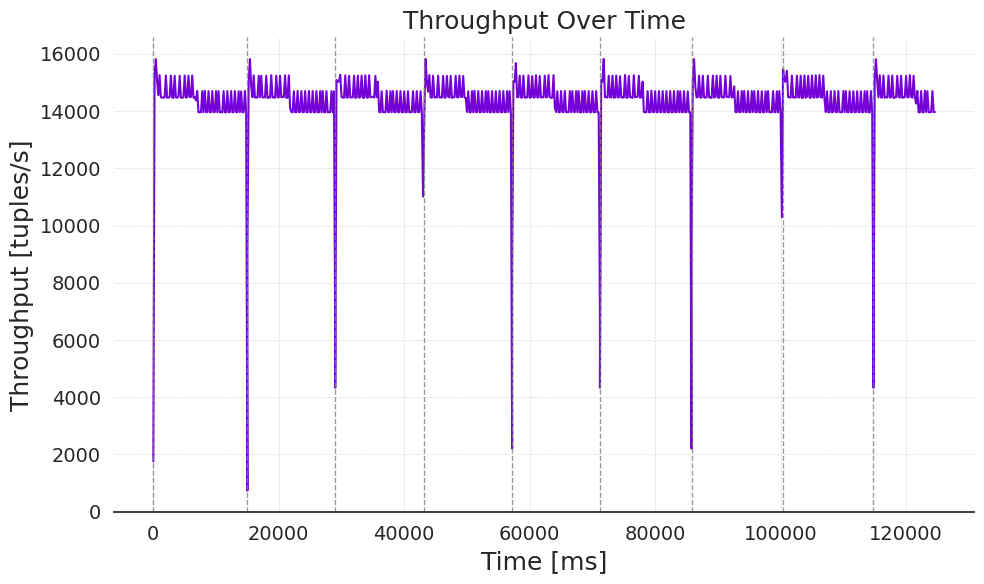

In [2]:
df = pd.read_csv("data_throughput_adaptive.csv")

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    df["timestamp_ms"],
    df["throughput_tup_per_s"],
    color=color_analytical,
    linewidth=1.5,
)

# Dashed vertical lines at first appearance of each query_id
query_transitions = df.drop_duplicates(subset="query_id", keep="first")
for _, row in query_transitions.iterrows():
    ax.axvline(x=row["timestamp_ms"], color="gray", linestyle="--", linewidth=1.0, alpha=0.8, label=row["query_id"])

ax.set_xlabel("Time [ms]", fontsize=18)
ax.set_ylabel("Throughput [tuples/s]", fontsize=18)
ax.set_title("Throughput Over Time", fontsize=18)
ax.tick_params(labelsize=14)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.savefig(f"{output_dir}/throughput_over_time.pdf")
plt.show()

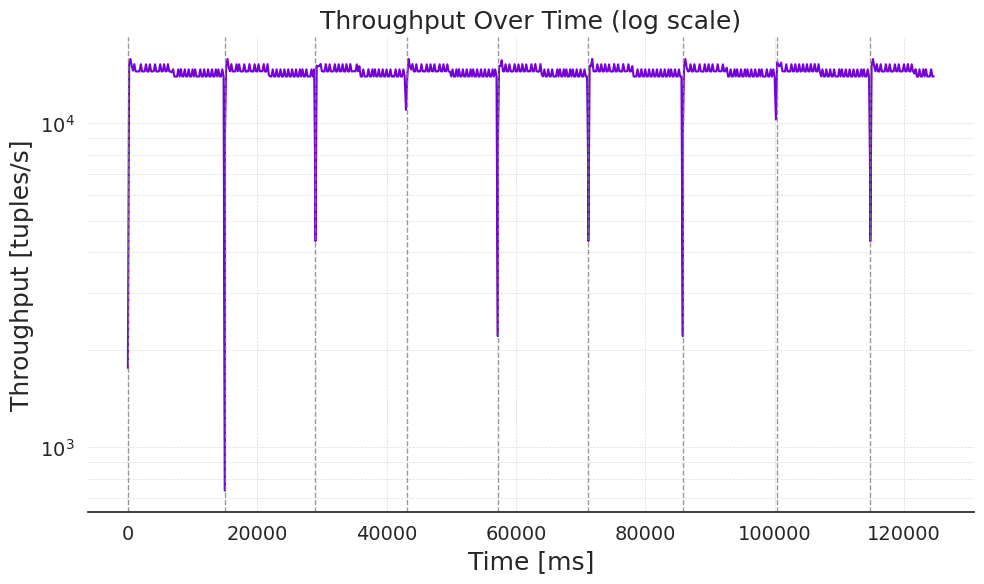

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    df["timestamp_ms"],
    df["throughput_tup_per_s"],
    color=color_analytical,
    linewidth=1.5,
)

for _, row in query_transitions.iterrows():
    ax.axvline(x=row["timestamp_ms"], color="gray", linestyle="--", linewidth=1.0, alpha=0.8, label=row["query_id"])

ax.set_yscale("log")
ax.set_xlabel("Time [ms]", fontsize=18)
ax.set_ylabel("Throughput [tuples/s]", fontsize=18)
ax.set_title("Throughput Over Time (log scale)", fontsize=18)
ax.tick_params(labelsize=14)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.savefig(f"{output_dir}/throughput_over_time_log.pdf")
plt.show()